# 8교시 | CLIP(Contrastive Language-Image Pre-training) 구조와 활용
**환경**: Google Colab | **방법**: 이론 + 실습
> 2일차 시작. Colab 런타임을 새로 연결하고 패키지를 재설치한다.

---

## 학습 목표

- CLIP(Contrastive Language-Image Pre-training)의 대조 학습(Contrastive Learning) 원리를 설명할 수 있다.
- 이미지-텍스트 임베딩 유사도를 직접 계산하고 Zero-shot 분류를 수행한다.
- VLM(Vision Language Model)에서 CLIP(Contrastive Language-Image Pre-training)이 Visual Encoder로 재사용되는 이유를 설명할 수 있다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 이미지와 텍스트를 같은 의미 공간에 놓아 비교하는 모델이 CLIP(Contrastive Language-Image Pre-training)이라는 점을 이해하는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: CLIP(Contrastive Language-Image Pre-training)은 "이미지와 문장을 같은 좌표계로 보내서 가장 가까운 것을 고르는 모델"이라고 이해하면 된다.
- 헷갈려도 괜찮은 부분: InfoNCE나 유사도 행렬 수식이 바로 익숙하지 않아도 된다. 먼저 매칭 쌍은 가깝게, 비매칭 쌍은 멀게 만든다는 원리가 중요하다.

```   
ResNet : 대표적인 CNN기반의 이미지 분류 모델로 정해진 이미지를 통한 분류만 가능  
         Zero-shot 분류는 불가능  
예) 고양이 개는 분류가능하나 공을 들고 있는 고양이는 분류 불가 - 학습 후 가능       

VLM : Vision Language Model, 이미지와 텍스트를 동시에 이해하는 모델  
      Language Model에 Vision Encoder를 붙여서 이미지와 텍스트를 동시에 이해하도록 학습
      Vision Encoder 모델을 만든다면 Language Model의 d_model(hidden size)과 맞추어야 하기 때문에 같거나 배수의 d_model을 가지도록 설계!!!

```

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| Contrastive Learning | 맞는 쌍은 가깝게, 틀린 쌍은 멀게 만드는 학습 |
| Image Encoder | 이미지를 벡터로 바꾸는 모델 부분 |
| Text Encoder | 문장을 벡터로 바꾸는 모델 부분 |
| Embedding Space | 의미가 비슷한 것끼리 가까워지는 좌표 공간 |
| Zero-shot | 따로 학습하지 않은 새 클래스도 바로 시험하는 방식 |
| Cosine Similarity | 두 벡터가 얼마나 비슷한 방향을 보는지 재는 값 |

---

## 이론

### 먼저 큰 그림부터 이해하기

CLIP은 한 문장으로 말하면, **이미지와 텍스트를 같은 의미 공간에서 비교할 수 있게 만든 모델**이다.  
기존 이미지 분류 모델은 `고양이`, `강아지`, `자동차`처럼 미리 정해 둔 클래스 안에서만 잘 동작했다. 반면 CLIP은 자연어 문장 자체를 비교 대상으로 사용하므로, 학습 때 정확히 같은 클래스 이름을 보지 않았더라도 **"어떤 문장이 이 이미지와 가장 잘 맞는가?"**라는 방식으로 예측할 수 있다.

이 관점이 중요한 이유는, 이후 멀티모달 모델(VLM)도 결국 이미지를 언어와 연결해야 하기 때문이다. CLIP은 바로 이 연결을 대규모 이미지-텍스트 쌍으로 먼저 학습한 모델이라고 보면 된다.

### CLIP (Contrastive Language-Image Pretraining, OpenAI 2021)

Radford et al. *"Learning Transferable Visual Models From Natural Language Supervision"*

- 인터넷에서 수집한 약 **4억 쌍의 (이미지, 텍스트)** 쌍으로 사전 학습
- Image Encoder (ViT 또는 ResNet) + Text Encoder (Transformer)를 **동시에** 학습
- 두 인코더의 출력을 **같은 임베딩 공간**에 정렬(align)

여기서 핵심은 두 인코더가 각각 따로 좋은 표현을 만드는 것이 아니라, **서로 비교 가능한 표현**을 만들도록 학습된다는 점이다. 즉, 이미지 인코더는 "이 이미지를 어떤 의미 벡터로 표현할까"를 배우고, 텍스트 인코더는 "이 문장을 어떤 의미 벡터로 표현할까"를 배우는데, 최종 목표는 둘이 같은 의미를 가리킬 때 가까워지게 만드는 것이다.  


- gpt2 : sequance 길이 고정되어 있는 한계 있는 것처럼 CLIP도 이미지와 텍스트를 각각 고정된 길이의 벡터로 바꾸는 한계가 있다.

### 입력에서 출력까지 한 번에 보기

CLIP의 실제 흐름은 아래처럼 이해하면 된다.

```
이미지
  ↓ Image Encoder
이미지 임베딩 벡터

텍스트 문장
  ↓ Text Encoder
텍스트 임베딩 벡터

두 벡터의 유사도 비교
  ↓
가장 가까운 텍스트를 선택하거나, 반대로 가장 가까운 이미지를 검색
```

즉, CLIP은 분류기(classifier)라기보다 먼저 **정렬된 표현 공간(aligned embedding space)** 을 만들고, 그 위에서 분류·검색·매칭을 수행하는 모델이다.

### 대조 학습 목표

```
배치 내 N개 (이미지, 텍스트) 쌍이 있을 때:

유사도 행렬 (N×N):
     텍스트1  텍스트2  텍스트3
이미지1 [ 높음   낮음   낮음 ]  ← 매칭 쌍(대각선) 유사도 ↑
이미지2 [ 낮음   높음   낮음 ]
이미지3 [ 낮음   낮음   높음 ]

손실 함수(InfoNCE):
  - 대각선 원소: 유사도 최대화
  - 비대각선 원소: 유사도 최소화
```

이 구조를 직관적으로 보면, 한 배치 안에서 모델은 매번 작은 "짝 맞추기 게임"을 푸는 셈이다.  
정답 이미지-텍스트 쌍은 서로 가깝게, 나머지 틀린 쌍은 멀어지게 만들어야 한다. 이 학습이 반복되면 결국 이미지와 텍스트가 같은 의미를 공유할수록 가까운 위치에 놓이는 공통 공간이 만들어진다.

그래서 CLIP의 핵심은 단순히 `정답 클래스 예측`이 아니라, **의미적으로 맞는 쌍을 구별하는 능력**이라고 이해하는 편이 더 정확하다.

### Zero-Shot 분류 원리

```
학습 때 본 적 없는 클래스도 분류 가능!

후보 레이블 = ["a photo of a cat", "a photo of a dog", "a photo of a car"]
  ↓ Text Encoder
3개의 텍스트 임베딩 벡터

쿼리 이미지
  ↓ Image Encoder
1개의 이미지 임베딩 벡터

코사인 유사도 계산 → 가장 유사한 텍스트 = 예측 레이블
```

여기서 중요한 점은 텍스트 후보가 고정된 분류 헤드 대신 동작한다는 것이다.  
기존 분류 모델은 마지막 선형층의 출력 차원이 클래스 수에 묶여 있지만, CLIP은 텍스트 문장을 바꾸는 것만으로 새 후보 클래스를 즉시 시험할 수 있다. 그래서 이를 **Zero-shot 분류**라고 부른다.

다만 CLIP은 어디까지나 후보들 중 상대적으로 가장 비슷한 텍스트를 고르는 구조이므로, 후보 문장을 어떻게 쓰는지에 따라 결과가 달라질 수 있다. 즉, `a photo of a dog`와 `a close-up photo of a dog`는 서로 다른 텍스트 임베딩을 만들며, 프롬프트 설계가 분류 결과에 영향을 줄 수 있다.

### VLM에서 CLIP의 역할

```
CLIP 학습 완료
  ↓
Image Encoder (ViT) 재사용
  ↓ MLP Projection (차원 맞춤)
LLM Decoder 연결
  ↓
VLM 완성 (LLaVA, InternVL, Qwen-VL...)
```

CLIP의 이미지 인코더는 이미 언어와 정렬된 임베딩 공간을 갖고 있기 때문에 LLM과 연결이 자연스럽다.

쉽게 말해, CLIP의 visual encoder는 이미지를 그냥 픽셀 덩어리가 아니라 **언어로 설명 가능한 의미 표현**에 가깝게 바꿔 준다. 그래서 여기에 projection layer를 붙여 LLM 입력 차원에 맞추면, LLM이 이미지를 "언어와 연결된 형태"로 받아들이기 쉬워진다.

이 때문에 LLaVA, BLIP-2, Qwen-VL 같은 모델 설명에서 `CLIP ViT`, `EVA-CLIP`, `InternViT` 같은 visual encoder 이름이 반복해서 등장한다.

### CLIP의 한계

- 정밀한 공간 관계 이해 부족 ("왼쪽에 있는 물체")
- 텍스트 OCR, 세밀한 숫자/기호 인식 약함 : 고해상도 필요
- 이 한계를 극복하기 위해 최신 VLM은 더 큰 전용 ViT(InternViT-6B 등)를 사용

이 한계가 생기는 이유도 같이 이해해 두는 것이 좋다. CLIP은 전역적인 이미지-텍스트 정렬에는 매우 강하지만, 아주 작은 글자나 세밀한 위치 관계처럼 **고해상도 세부 정보**를 끝까지 보존하는 데는 상대적으로 약할 수 있다. 즉, `이 사진이 전반적으로 무엇을 보여 주는가`에는 강하지만, `왼쪽 아래의 작은 표지판에 적힌 숫자`처럼 미세한 정보에는 약해질 수 있다. 

- 절대위치로 위치벡터 사용하기 때문 - > 상대위치로 변환(gpt3부터 ) RoPE(Rotary회전각(radian) Position Embedding) 사용
- M-Rope : RoPE를 multi-dimensional로 확장한 것, 2차원 이미지에 적용 가능 
           RoPE는 1D-RoPE 1차원 RoPE
           2D-RoPE 2차원 RoPE (이미지 - h, w)
           3D-RoPE 3차원 RoPE (비디오 - h, w, t(time-Frame))  

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

이 단원에서는 아래 흐름이 머릿속에 연결되어야 한다.

1. CLIP은 이미지와 텍스트를 같은 공간으로 보낸다.
2. 같은 의미의 이미지와 문장은 가까워지도록 대조 학습한다.
3. 그래서 텍스트 후보를 바꾸는 것만으로 Zero-shot 분류가 가능하다.
4. 이 정렬된 visual encoder는 이후 VLM의 입력부로 재사용되기 좋다.
5. 다만 세밀한 OCR·공간 관계에는 한계가 있어 더 큰 비전 인코더가 등장했다.

---

## 실습

### 자주 막히는 오류

- `clip` import 오류: OpenAI CLIP 저장소 설치가 빠졌는지 먼저 확인한다.
- 이미지가 안 뜸: URL 응답 실패나 네트워크 문제일 수 있으니 이미지 로드 함수부터 다시 본다.
- 확률이 100%처럼 나오지 않음: 후보 클래스가 여러 개면 softmax 분배 결과라서 나뉘는 것이 정상이다.
- 없는 클래스에도 점수가 나옴: CLIP은 규칙 기반 분류기가 아니라 상대적 유사도 비교 모델이기 때문이다.

### 실패했을 때 체크 순서

1. 이미지와 텍스트 입력이 모두 준비됐는지 확인한다: 하나라도 비어 있으면 유사도 비교가 성립하지 않는다.
2. 지금 보는 값이 raw similarity인지 softmax 확률인지 구분한다: 두 값을 섞어 읽으면 해석이 흔들린다.
3. 후보 문장을 줄여 다시 실행한다: 클래스 수를 줄이면 어떤 비교가 작동하는지 더 선명하게 보인다.

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시의 실습은 크게 세 부분이다.

1. CLIP 모델과 후보 텍스트를 준비하기
2. 이미지-텍스트 유사도로 Zero-shot 분류 결과를 확인하기
3. 이미지-텍스트 유사도 행렬을 heatmap으로 시각화하기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### Step 0. 실습 준비

먼저 필요한 패키지를 설치하고 기본 라이브러리를 import한다.



In [ ]:
!pip install -q transformers torch openai pillow matplotlib seaborn requests
!pip install -q git+https://github.com/openai/CLIP.git

import os
import clip
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image

  Preparing metadata (setup.py) ... done




이 단계에서 확인할 점:

- 패키지 설치 오류가 없는가?
- `clip` import가 정상적으로 되는가?

### Step 1. 디바이스와 CLIP 모델 준비

이번 실습에서는 CLIP의 이미지 인코더와 텍스트 인코더를 함께 사용한다.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"디바이스: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)

print("CLIP 모델 로드 완료")
print(f"Image Encoder 입력 해상도: {model.visual.input_resolution}")
print(f"임베딩 차원: {model.visual.output_dim}")

디바이스: cpu
CLIP 모델 로드 완료
Image Encoder 입력 해상도: 224
임베딩 차원: 512


이 단계에서 확인할 점:

- `디바이스: cpu`는 지금 실습이 GPU가 아니라 CPU에서 실행된다는 뜻이다. 즉, 코드가 잘못된 것은 아니고 현재 Colab 런타임에서 GPU가 연결되지 않았거나 사용하지 않는 상태라고 이해하면 된다. CPU에서도 실습은 가능하지만, 실행 속도는 GPU보다 느릴 수 있다.
- 진행 막대 뒤에 `CLIP 모델 로드 완료`가 출력되면, CLIP 가중치 파일 다운로드와 모델 초기화가 정상적으로 끝났다는 뜻이다. 처음 실행할 때는 모델 파일을 내려받느라 시간이 조금 걸릴 수 있고, 다음 단계부터는 이 로드된 모델을 계속 사용하게 된다.
- `Image Encoder 입력 해상도: 224`는 CLIP의 이미지 인코더가 기본적으로 `224×224` 크기 입력을 기준으로 동작한다는 뜻이다. 즉, 이후 `preprocess(img)`는 이미지를 모델이 기대하는 크기와 형식에 맞게 바꾸는 역할을 한다고 연결해서 이해하면 된다.
- `임베딩 차원: 512`는 이미지든 텍스트든 최종적으로 길이 512의 벡터로 표현된다는 뜻이다. 여기서 중요한 점은 이미지와 텍스트가 서로 다른 입력이지만, 비교할 때는 같은 길이의 벡터 공간으로 들어간다는 것이다.
- 왜 이것이 중요하냐 하면, Zero-shot 분류는 "이미지 벡터 1개"와 "텍스트 벡터 여러 개"의 유사도를 직접 비교하는 구조이기 때문이다. 만약 두 벡터의 차원이 다르면 비교가 불가능하므로, CLIP은 둘 다 같은 512차원 임베딩 공간으로 맞춰 놓는다.
- 따라서 이 단계의 핵심은 "CLIP이 이미지와 텍스트를 같은 의미 공간으로 보내기 위한 준비를 마쳤고, 이후 단계에서는 이 512차원 벡터들끼리 유사도를 비교하게 된다"는 점을 출력으로 확인하는 것이다.

### Step 2. 이미지 로드 함수와 후보 텍스트 준비

비교할 이미지들과 후보 텍스트 프롬프트를 준비한다. 이 텍스트 프롬프트들이 CLIP의 "분류 레이블" 역할을 한다.

In [ ]:
def load_image(url):
  response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=20,
  )
  response.raise_for_status()

  content_type = response.headers.get("Content-Type", "")
  if not content_type.startswith("image/"):
    raise ValueError(f"이미지 응답이 아닙니다: {content_type} | URL={url}")

  return Image.open(BytesIO(response.content)).convert("RGB")

urls = {
  "cat": "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
  "dog": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
  "car": "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?auto=format&fit=crop&w=1200&q=80",
}

text_prompts = [
  "a photo of a cat",
  "a photo of a dog",
  "a photo of a car",
  "a photo of a bird",
  "a photo of a flower",
]

text_tokens = clip.tokenize(text_prompts).to(device)

print(f"이미지 수: {len(urls)}")
print(f"텍스트 후보 수: {len(text_prompts)}")
print(text_prompts)

이미지 수: 3
텍스트 후보 수: 5
['a photo of a cat', 'a photo of a dog', 'a photo of a car', 'a photo of a bird', 'a photo of a flower']


이 단계에서 확인할 점:

- `이미지 수: 3`은 지금 실험에 사용할 이미지가 `cat`, `dog`, `car` 세 장이라는 뜻이다. 즉, 이후 단계에서는 이 세 이미지를 하나씩 CLIP에 넣어 텍스트 후보들과 비교하게 된다.
- `텍스트 후보 수: 5`는 비교 대상 문장이 다섯 개 준비되었다는 뜻이다. 여기서 중요한 점은 CLIP이 미리 고정된 정답 클래스를 출력하는 것이 아니라, 우리가 직접 넣어 준 다섯 개 문장 중 어떤 문장이 가장 이미지와 비슷한지를 비교한다는 것이다.
- 출력된 리스트 `['a photo of a cat', 'a photo of a dog', 'a photo of a car', 'a photo of a bird', 'a photo of a flower']`는 단순한 문자열 모음이 아니라, 곧 Zero-shot 분류의 후보 레이블 집합이다. 즉, 나중에 막대그래프와 heatmap에서 보게 될 점수들은 모두 이 다섯 문장에 대한 점수라고 이해하면 된다.
- 여기서 `cat`, `dog`, `car`는 실제로 준비한 이미지와 대응되는 후보이고, `bird`, `flower`는 일부러 넣어 둔 "없는 후보"다. 이렇게 해야 CLIP이 맞는 후보에 높은 점수를 주는지, 그리고 실제로 이미지에 없는 클래스에는 점수를 어떻게 나누는지 함께 관찰할 수 있다.
- 또 한 가지 중요한 점은, CLIP은 텍스트를 그냥 단어 이름으로만 받는 것이 아니라 `a photo of a ...` 같은 자연어 문장 형태로 받는다는 것이다. 즉, 이 단계는 "분류 레이블을 숫자 클래스가 아니라 문장 프롬프트로 준비한다"는 점을 확인하는 단계이기도 하다.
- 따라서 이 단계의 핵심은 "비교할 이미지 3개와 후보 문장 5개가 준비되었고, 다음 단계부터는 각 이미지를 이 다섯 문장과 같은 의미 공간에서 직접 비교한다"는 점을 출력으로 확인하는 것이다.

### Step 3. 텍스트 임베딩 만들기

먼저 텍스트 후보들을 임베딩 벡터로 바꾼다. 이후 각 이미지와 이 벡터들을 비교하게 된다.

In [ ]:
with torch.no_grad():
  text_features = model.encode_text(text_tokens)
  text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"텍스트 임베딩 shape: {text_features.shape}")

텍스트 임베딩 shape: torch.Size([5, 512])


이 단계에서 확인할 점:

- `텍스트 임베딩 shape: torch.Size([5, 512])`는 `텍스트 후보 5개`, `각 텍스트를 표현하는 벡터 길이 512`라고 읽으면 된다. 즉, 앞 단계에서 준비한 다섯 개 문장이 이제 각각 하나의 숫자 벡터로 바뀌었다는 뜻이다.
- 여기서 앞의 `5`는 텍스트 프롬프트 개수와 정확히 대응된다. 즉, `a photo of a cat`, `a photo of a dog`, `a photo of a car`, `a photo of a bird`, `a photo of a flower` 이 다섯 문장 각각이 임베딩 벡터 하나씩을 갖게 된 것이다.
- 뒤의 `512`는 문장 하나를 표현하는 임베딩 차원이다. 다시 말해, 텍스트 한 문장은 길이 512의 숫자 목록으로 바뀌어 CLIP 내부에서 의미를 담게 된다. 이 512차원은 Step 1에서 본 이미지 임베딩 차원 512와 맞춰져 있기 때문에, 나중에 이미지 벡터와 직접 비교할 수 있다.
- 중요한 점은, 이제 CLIP이 문장을 단순한 문자열로 비교하는 것이 아니라 "의미를 담은 벡터"로 비교한다는 것이다. 즉, 이후 단계에서 계산하는 것은 단어 일치 여부가 아니라, 이미지 벡터와 텍스트 벡터가 의미 공간에서 얼마나 가까운지를 보는 과정이다.
- 코드에서 바로 아래 줄의 정규화(`text_features / norm`)는 각 벡터의 길이를 1로 맞추는 과정이다. 이렇게 해야 벡터 크기 자체보다 방향, 즉 의미적 유사성에 더 집중해서 비교할 수 있다. 그래서 이후 similarity 계산을 코사인 유사도처럼 해석하기 쉬워진다.
- 따라서 이 단계의 핵심은 "다섯 개 텍스트 프롬프트가 모두 512차원 의미 벡터로 바뀌었고, 이제 다음 단계에서는 이미지 임베딩과 이 텍스트 임베딩들을 직접 비교할 준비가 끝났다"는 점을 shape로 확인하는 것이다.

### Step 4. Zero-shot 분류 결과 시각화하기

이제 각 이미지에 대해 이미지 임베딩을 만들고, 텍스트 임베딩과 유사도를 계산해 Zero-shot 분류 결과를 본다.

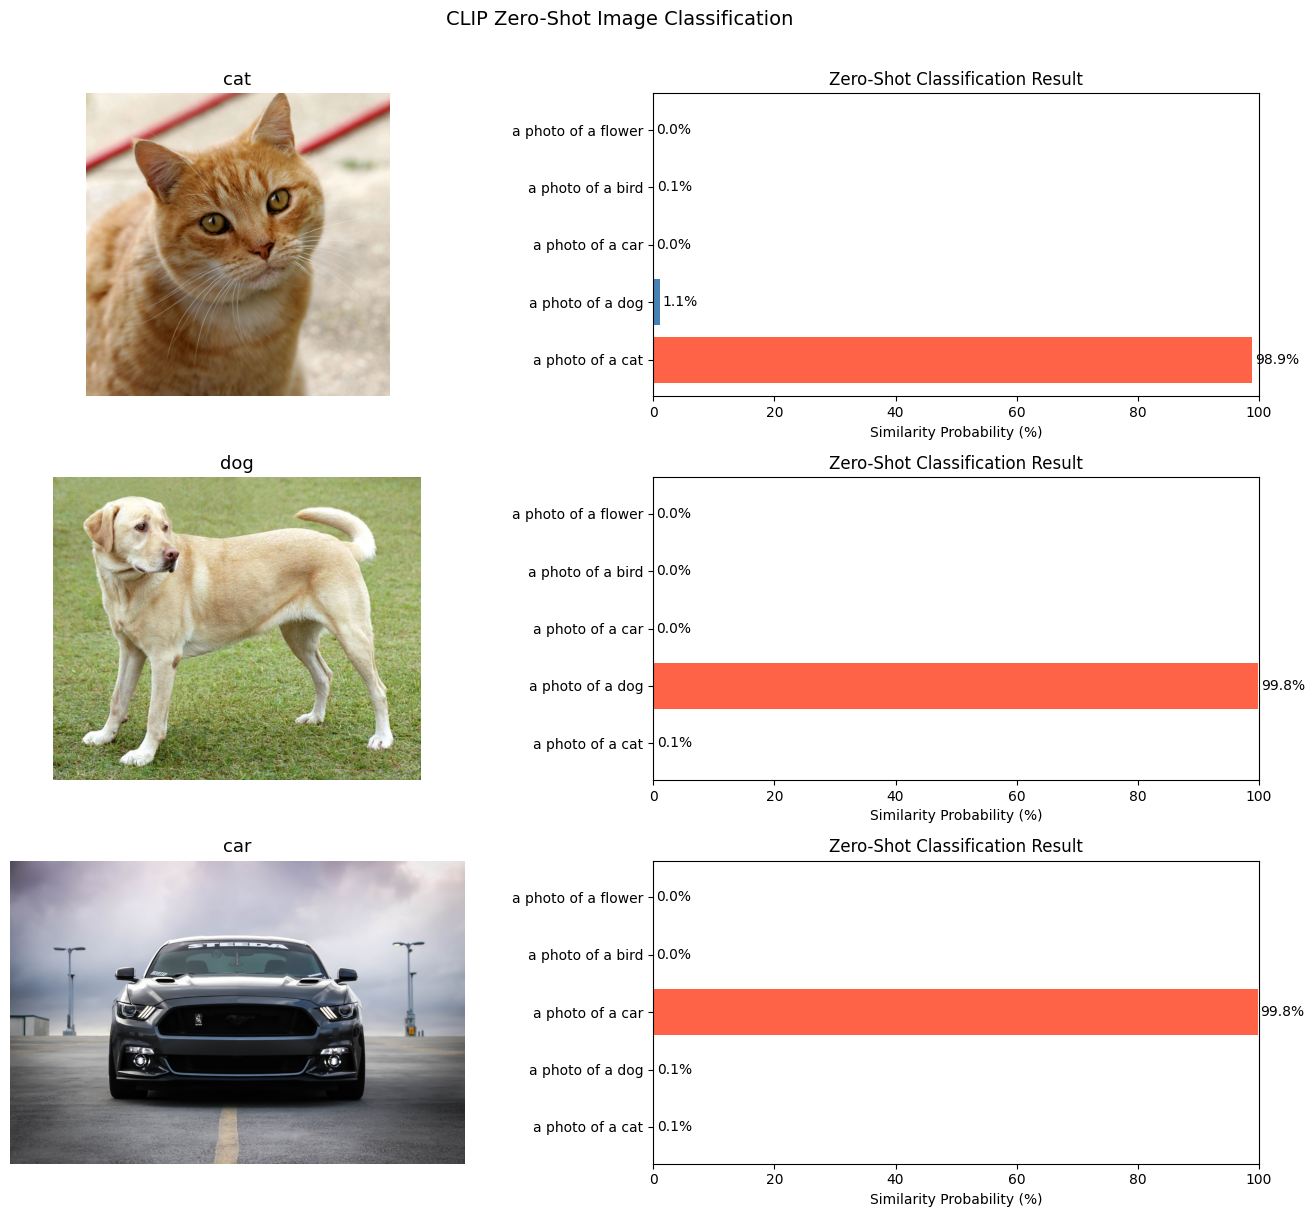

In [ ]:
fig, axes = plt.subplots(len(urls), 2, figsize=(14, 4 * len(urls)))

with torch.no_grad():
  for row, (img_name, url) in enumerate(urls.items()):
    img = load_image(url)
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    # 이미지 임베딩 생성 후 정규화
    img_features = model.encode_image(img_tensor)
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)

    # 이미지-텍스트 유사도 계산 후 확률처럼 해석하기 위해 softmax 적용
    similarity = (100.0 * img_features @ text_features.T).softmax(dim=-1)
    probs = similarity[0].cpu().numpy()

    # 원본 이미지 표시
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(img_name, fontsize=13)
    axes[row, 0].axis("off")

    # 후보 텍스트별 확률 시각화
    colors = ["tomato" if prob == probs.max() else "steelblue" for prob in probs]
    bars = axes[row, 1].barh(text_prompts, probs * 100, color=colors)
    axes[row, 1].set_xlabel("Similarity Probability (%)")
    axes[row, 1].set_xlim(0, 100)
    axes[row, 1].set_title("Zero-Shot Classification Result")

    for bar, prob in zip(bars, probs):
      axes[row, 1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{prob * 100:.1f}%",
        va="center",
        fontsize=10,
      )

plt.suptitle("CLIP Zero-Shot Image Classification", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 이 결과는 각 행을 왼쪽에서 오른쪽으로 읽으면 된다. 왼쪽은 입력 이미지이고, 오른쪽 막대그래프는 그 이미지가 다섯 개 텍스트 후보와 각각 얼마나 비슷한지를 확률처럼 표시한 것이다. 즉, 막대가 가장 긴 문장이 현재 이미지에 대해 CLIP이 가장 잘 맞는다고 본 후보다.
- 첫 번째 행에서는 고양이 이미지에 대해 `a photo of a cat`이 약 `98.9%`로 가장 높고, `dog`는 `1.1%`, 나머지는 거의 `0%`에 가깝다. 이것은 CLIP이 고양이 이미지를 다른 후보들보다 `cat` 문장과 훨씬 더 가깝게 본다는 뜻이다.
- 두 번째 행에서는 강아지 이미지에 대해 `a photo of a dog`가 약 `99.8%`로 가장 높게 나온다. `cat`이 아주 작게 남아 있는 것은 완전히 이상한 것이 아니다. CLIP은 규칙 기반으로 "강아지면 무조건 dog만 100%"라고 판단하는 것이 아니라, 시각적으로 어느 후보와 더 비슷한지를 연속적인 점수로 비교하기 때문이다.
- 세 번째 행에서는 자동차 이미지에 대해 `a photo of a car`가 약 `99.8%`로 가장 높고, `cat`, `dog`, `bird`, `flower`는 거의 `0%` 수준이다. 즉, 자동차는 다른 동물 후보들과 의미적으로 매우 멀다고 판단되므로 점수가 거의 가지 않는다고 해석할 수 있다.
- 여기서 중요한 점은, `bird`와 `flower`처럼 실제 이미지에 없는 클래스도 후보에 포함되어 있다는 것이다. 그래도 이 후보들이 거의 점수를 받지 못하는 모습을 통해, CLIP이 단순히 아무 문장에나 비슷하다고 하는 것이 아니라 상대적으로 더 맞는 문장을 골라 낸다는 점을 확인할 수 있다.
- 또 하나 주의할 점은, 이 값들이 절대적인 진실값이라기보다 "현재 넣은 후보 5개 안에서의 상대적 분포"라는 것이다. 즉, 후보 문장을 바꾸면 확률 분배도 함께 달라질 수 있다. 그래서 CLIP의 Zero-shot 분류는 정해진 클래스 ID를 찍는 방식이 아니라, 자연어 후보 문장들 사이의 경쟁 결과라고 이해하는 것이 정확하다.
- 따라서 이 단계의 핵심은 "CLIP이 이미지와 텍스트를 같은 의미 공간에서 비교해, 고양이-`cat`, 강아지-`dog`, 자동차-`car`처럼 가장 가까운 자연어 후보를 스스로 선택한다"는 점을 막대그래프로 확인하는 것이다.

### Step 5. 이미지-텍스트 유사도 행렬 그리기

이번 단계에서는 각 이미지가 전체 텍스트 후보들과 얼마나 유사한지 heatmap으로 한 번에 본다.


[Image-Text Cosine Similarity Matrix]


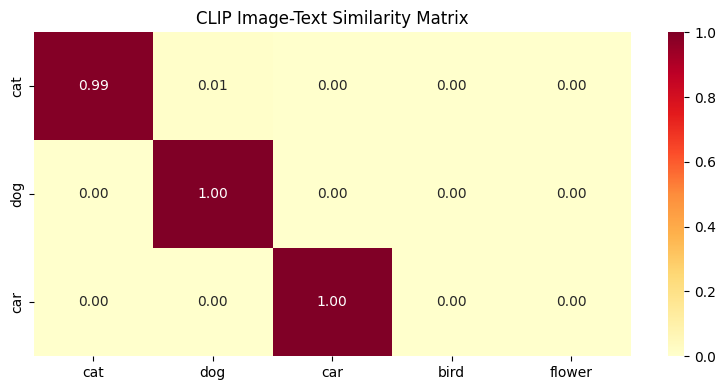

In [ ]:
print("\n[Image-Text Cosine Similarity Matrix]")

all_imgs = list(urls.keys())

with torch.no_grad():
  img_features_list = []

  for url in urls.values():
    img = preprocess(load_image(url)).unsqueeze(0).to(device)
    feat = model.encode_image(img)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    img_features_list.append(feat)

  img_features_all = torch.cat(img_features_list)
  similarity_matrix = (100.0 * img_features_all @ text_features.T).softmax(dim=-1)
  matrix = similarity_matrix.cpu().numpy()

plt.figure(figsize=(8, 4))
sns.heatmap(
  matrix,
  xticklabels=[prompt.replace("a photo of a ", "") for prompt in text_prompts],
  yticklabels=all_imgs,
  annot=True,
  fmt=".2f",
  cmap="YlOrRd",
  vmin=0,
  vmax=1,
)
plt.title("CLIP Image-Text Similarity Matrix")
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 이 heatmap은 `행 = 이미지`, `열 = 텍스트 후보`로 읽으면 된다. 즉, 왼쪽의 `cat`, `dog`, `car`는 이미지 쪽이고, 아래쪽의 `cat`, `dog`, `car`, `bird`, `flower`는 비교 대상 텍스트 문장에 해당한다. 각 칸의 숫자는 "이 이미지가 이 텍스트와 얼마나 비슷한가"를 확률처럼 나타낸 값이다.
- 색이 진할수록 값이 크고, 색이 옅을수록 값이 작다. 따라서 진한 빨간색 칸은 해당 이미지와 텍스트가 매우 잘 맞는 경우이고, 거의 흰색에 가까운 칸은 상대적으로 잘 맞지 않는 경우라고 이해하면 된다.
- 이 결과에서는 `cat-cat`, `dog-dog`, `car-car` 위치의 대각선 값이 각각 약 `0.99`, `1.00`, `1.00`으로 가장 크다. 이것은 고양이 이미지는 `cat` 텍스트와, 강아지 이미지는 `dog` 텍스트와, 자동차 이미지는 `car` 텍스트와 가장 가깝게 정렬되어 있다는 뜻이다.
- 반대로 대각선 밖의 칸들은 대부분 `0.00` 또는 아주 작은 값이다. 예를 들어 고양이 이미지가 `dog`와는 약 `0.01` 정도만 연결되고, 자동차가 `bird`나 `flower`와는 거의 연결되지 않는 모습이 보인다. 이는 맞지 않는 이미지-텍스트 쌍은 임베딩 공간에서 멀리 떨어져 있다는 뜻으로 해석하면 된다.
- 여기서 특히 중요한 것은 "대각선이 높다"는 것이 단순히 숫자가 예쁘게 나온다는 뜻이 아니라, CLIP의 대조 학습 목표가 실제로 반영되었다는 증거라는 점이다. 맞는 쌍은 가깝게, 틀린 쌍은 멀게 학습했기 때문에, heatmap에서도 대각선이 가장 진하게 나타난다.
- 또 `bird`, `flower`처럼 실제 이미지에 없는 후보 열이 거의 전부 옅게 보이는 것도 중요한 관찰이다. 이것은 CLIP이 아무 문장에나 높은 점수를 주는 것이 아니라, 이미지와 의미적으로 잘 맞는 텍스트에만 높은 점수를 주고 있음을 보여 준다.
- 따라서 이 단계의 핵심은 "CLIP이 이미지와 텍스트를 같은 임베딩 공간에 정렬해 두었기 때문에, 맞는 쌍은 heatmap의 대각선에서 높게 나타나고 틀린 쌍은 낮게 나타난다"는 점을 한눈에 확인하는 것이다.

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. CLIP은 이미지와 텍스트를 같은 임베딩 공간으로 보낸다.
2. 텍스트 프롬프트가 Zero-shot 분류에서 후보 레이블 역할을 한다.
3. 이미지와 텍스트 임베딩의 유사도를 비교해 분류를 수행할 수 있다.
4. 없는 클래스도 후보에 넣을 수 있지만, 실제 이미지와 유사한 정도에 따라 확률이 분배된다.
5. CLIP의 공통 임베딩 공간은 이후 VLM의 visual encoder로 재사용되기 좋다.

**관찰 과제**

1. 대각선(매칭 쌍)의 유사도가 비대각선보다 높은지 확인
2. "bird", "flower"처럼 없는 클래스의 확률은 어떻게 분배되는지 관찰
3. 강아지 이미지에서 고양이 확률이 얼마나 나오는지 — 시각적 유사도 반영 여부

---

## 핵심 개념 정리

```
CLIP = Image Encoder + Text Encoder → 공통 임베딩 공간

학습 방법: 매칭 쌍 유사도↑, 비매칭 쌍 유사도↓ (대조 학습)

활용:
  - Zero-shot 이미지 분류
  - 이미지 검색
  - VLM의 Visual Encoder로 재사용 (LLaVA, BLIP-2 등)
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. CLIP의 대조 학습은 대각선과 비대각선 유사도에 대해 어떤 목표를 가지는가?
2. Zero-shot 분류에서 텍스트 프롬프트가 왜 "레이블"처럼 동작하는가?
3. 이미지 임베딩과 텍스트 임베딩을 정규화하는 이유는 무엇인가?
4. CLIP이 VLM의 visual encoder로 재사용되기 쉬운 이유는 무엇인가?
5. CLIP이 OCR이나 정밀한 공간 관계 이해에 약한 이유는 무엇인가?

---

## 다음 교시 예고

**9교시 (통합)**: OpenAI API로 텍스트 LLM 추론 실험을 먼저 진행하고, 이어서 이미지를 base64로 인코딩하여 VLM Captioning을 구현한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **그래프와 유사도 행렬을 보고 왜 그런 결과가 나왔는지 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. 대각선(매칭 쌍)의 유사도가 비대각선보다 높은지 확인**

일반적으로 고양이-`cat`, 강아지-`dog`, 자동차-`car`처럼 맞는 쌍은 대각선 위치에서 더 높은 확률을 보인다. 이는 CLIP이 학습 과정에서 매칭 쌍의 유사도를 높이고 비매칭 쌍의 유사도를 낮추도록 훈련되었기 때문이다. 즉, 유사도 행렬의 대각선이 상대적으로 높게 나오는 것은 CLIP의 대조 학습 목표가 제대로 반영된 결과라고 볼 수 있다.

**2. `bird`, `flower`처럼 없는 클래스의 확률은 어떻게 분배되는지 관찰**

이미지에 해당 클래스가 실제로 없더라도 확률이 완전히 0이 되지는 않는다. CLIP은 후보들 중 상대적으로 더 비슷한 텍스트에 확률을 분배하기 때문이다. 즉, 없는 클래스도 시각적으로 비슷하거나 애매한 경우 어느 정도 점수를 받을 수 있다. 이 관찰을 통해 CLIP의 출력이 절대적인 정답 판정이 아니라, 후보들 사이의 상대적 유사도 비교라는 점을 이해할 수 있다.

**3. 강아지 이미지에서 고양이 확률이 얼마나 나오는지 — 시각적 유사도 반영 여부**

강아지 이미지에서 `dog`가 가장 높더라도 `cat` 확률이 완전히 0은 아닐 수 있다. 이는 둘 다 털이 있는 동물이고 얼굴 구조나 촬영 구도 같은 시각적 특징이 일부 겹치기 때문이다. 즉, CLIP은 딱 잘라 규칙 기반으로 분류하는 것이 아니라 시각적 유사도에 따라 연속적으로 점수를 주기 때문에, 비슷한 클래스끼리는 어느 정도 확률이 남을 수 있다.

### 혼자 점검하기 모범 답안

**1. CLIP의 대조 학습은 대각선과 비대각선 유사도에 대해 어떤 목표를 가지는가?**

대각선은 서로 매칭되는 이미지-텍스트 쌍이므로 유사도를 높이는 것이 목표다. 반면 비대각선은 매칭되지 않는 쌍이므로 유사도를 낮추는 것이 목표다. 즉, CLIP은 맞는 쌍은 가깝게, 틀린 쌍은 멀어지도록 같은 임베딩 공간을 학습한다.

**2. Zero-shot 분류에서 텍스트 프롬프트가 왜 "레이블"처럼 동작하는가?**

CLIP은 텍스트 문장을 임베딩 벡터로 바꾸고, 이미지 임베딩과의 유사도를 계산할 수 있다. 그래서 `a photo of a cat`, `a photo of a dog` 같은 문장은 실제 분류 레이블 이름 대신 자연어 후보로 쓰일 수 있다. 이미지와 가장 유사한 텍스트 프롬프트가 곧 예측 결과가 된다.

**3. 이미지 임베딩과 텍스트 임베딩을 정규화하는 이유는 무엇인가?**

정규화를 하면 벡터 길이 차이의 영향을 줄이고 방향 중심으로 비교할 수 있어, 코사인 유사도처럼 해석하기가 쉬워진다. 즉, 벡터 크기보다 내용의 방향성, 곧 의미적 유사성에 더 집중할 수 있게 된다.

**4. CLIP이 VLM의 visual encoder로 재사용되기 쉬운 이유는 무엇인가?**

CLIP의 이미지 인코더는 이미 텍스트와 정렬된 임베딩 공간을 형성하고 있기 때문이다. 즉, 이미지 특징이 언어 정보와 연결되기 쉬운 표현으로 바뀌어 있으므로, 이를 LLM과 연결하면 멀티모달 모델을 만들기 유리하다.

**5. CLIP이 OCR이나 정밀한 공간 관계 이해에 약한 이유는 무엇인가?**

CLIP은 전반적인 이미지-텍스트 정렬에는 강하지만, 아주 작은 글자나 복잡한 공간 관계처럼 세밀한 정보에는 상대적으로 약할 수 있다. 이는 입력 해상도와 인코더 크기, 학습 목표의 특성 때문에 세부 구조보다 전역적 의미 정렬에 더 최적화되어 있기 때문이다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 막대그래프와 heatmap을 보고 스스로 해석해 본다.
2. 그다음 모범 답안과 비교한다.
3. 숫자가 조금 달라도 상대적 유사도 관계를 설명하면 이해한 것으로 본다.
4. 설명이 막히면 다시 후보 텍스트와 확률 분포를 확인한다.